# Storm tracking over Indonesia

Detects and tracks storms in GPM IMERG half-hourly precipitation, and writes a
catalogue with date and time, total volume, duration, max intensity, centroid,
weighted centroid, start and end location, and the trackline.

**Set the date range in the next cell. Everything else follows from it.**
No local archive is required: by default the data is fetched from NASA GES DISC
with server-side subsetting and cached, so only the chosen period is downloaded.

### Scope, stated up front

This produces a **catalogue**, not a validated product. There is no gauge or radar
comparison for Indonesia in this project, so nothing here should be read as a
statement of accuracy. See the README section on what this is not.


## 1. Choose the period

One day is about 16 s and 3.9 MB over the network. One month is about 8 min and
121 MB, and gives a 511 MB cube. A month is the online ceiling; beyond it set
`SOURCE = "local"`.


In [1]:
START   = "2020-12-01"
END     = "2020-12-05"     # inclusive

SOURCE  = None             # None = config default (opendap). Or "local".
PRODUCT = "final"          # final | late | early

# Segmentation. PROMINENCE is the one parameter that decides what counts as a
# distinct storm, in mm/hr. It is NOT scale-free: the storm count roughly halves
# for each doubling. Quote it alongside every number you take from the catalogue.
WET_THRESHOLD = 1.0
PROMINENCE    = 4.0
MIN_VOXELS    = 6

## 2. Setup

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt

from imerg_io import load_range, cell_area_m2
from segment import label_ccl, label_watershed, percolation_share
from mergetree import build_merge_tree, segment_at
from storms import storm_table, track_wkt
import catalogue, severity

pd.set_option("display.width", 180)
plt.rcParams["figure.dpi"] = 110

## 3. Gather the data

`load_range` raises on a missing day rather than leaving a silent gap, because a
gap would read downstream as a storm ending and restarting.

In [3]:
da = load_range(START, END, source=SOURCE, product=PRODUCT)
R  = da.values
print(da.sizes, f"{R.nbytes/1e6:.0f} MB")
print(f"units {da.attrs.get('units', 'mm/hr')}, "
      f"max {np.nanmax(R):.1f}, wet>=1mm/h {100*(R>=1).mean():.1f}%")

Frozen({'time': 240, 'lat': 182, 'lon': 472}) 82 MB
units mm/hr, max 76.6, wet>=1mm/h 9.9%


### Domain rainfall through the window

`precipitation` is an intensity in mm/hr, so depth per half-hourly step is
`R * 0.5` mm. Omitting the 0.5 is a factor-of-two error.

peak step (UTC): 2020-12-04T20:30


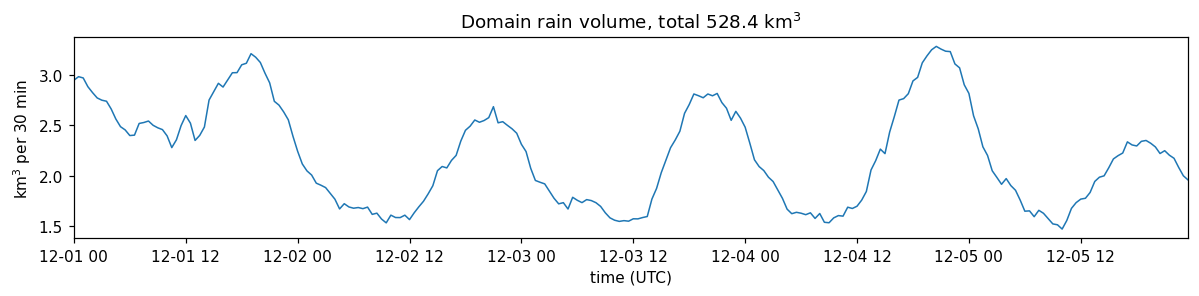

In [4]:
from imerg_io import cell_area_m2
from config import DT_HOURS

area = cell_area_m2(da.lat.values)[None, :, None]
vol_per_step = (np.nan_to_num(R) * DT_HOURS / 1000.0 * area).sum(axis=(1, 2)) / 1e9

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(da.time.values, vol_per_step, lw=1)
ax.set_ylabel("km$^3$ per 30 min"); ax.set_xlabel("time (UTC)")
ax.set_title(f"Domain rain volume, total {vol_per_step.sum():.1f} km$^3$")
ax.margins(x=0); fig.tight_layout()

# Timestamps are UTC. Indonesia spans UTC+7 to +9, so the diurnal cycle is offset.
print("peak step (UTC):", str(da.time.values[vol_per_step.argmax()])[:16])

## 4. Why not the published method

ST-CORA thresholds the field and labels connected components. Over this
domain that percolates: one object swallows most of the rain. The cell below
shows the trade the baseline cannot escape, and what a partition does instead.

In [5]:
tree = build_merge_tree(R, WET_THRESHOLD)
print(f"merge tree: {len(tree):,} components")

rows = []
for name, lab in [
    ("CCL thr=1.0 (as published)", label_ccl(R, 1.0, MIN_VOXELS)),
    ("CCL thr=5.0 (de-percolated)", label_ccl(R, 5.0, MIN_VOXELS)),
    (f"watershed h={PROMINENCE}",
     label_watershed(R, WET_THRESHOLD, PROMINENCE, MIN_VOXELS)),
    (f"merge tree h={PROMINENCE}",
     segment_at(tree, R, PROMINENCE, MIN_VOXELS)),
]:
    c = np.bincount(lab.ravel()); c[0] = 0
    rows.append({"method": name, "storms": int((c > 0).sum()),
                 "largest_object_share": percolation_share(lab),
                 "wet_captured": c.sum() / max((R >= 1.0).sum(), 1)})
pd.DataFrame(rows).round(4)

merge tree: 54,337 components


,method,storms,largest_object_share,wet_captured
0,CCL thr=1.0 (as published),3705,0.2886,0.9913
1,CCL thr=5.0 (de-percolated),1973,0.1321,0.1929
2,watershed h=4.0,4852,0.0049,0.9511
3,merge tree h=4.0,6959,0.0048,0.9704


Read the two rightmost columns together. The baseline either keeps the rain
and percolates, or de-percolates by discarding most of it. A partition does
both, because every wet voxel belongs to exactly one storm.

The merge tree and the direct watershed agree on where boundaries fall to
about 98.8%, but the tree yields more objects at the same `h` and is roughly
8x cheaper to re-cut, because it is built once and cut many times.

## 5. Build the catalogue

In [6]:
df = catalogue.build(START, END, source=SOURCE, product=PRODUCT,
                     wet_threshold=WET_THRESHOLD, prominence=PROMINENCE,
                     min_voxels=MIN_VOXELS)
print(f"{len(df)} storms, {df.total_volume_km3.sum():.1f} km3")
df.sort_values("total_volume_km3", ascending=False).head(10)[[
    "start_time", "end_time", "duration_h", "total_volume_km3",
    "max_intensity_mm_hr", "max_area_km2",
    "start_lat", "start_lon", "end_lat", "end_lon"]]

6959 storms, 445.0 km3


,start_time,end_time,duration_h,total_volume_km3,max_intensity_mm_hr,max_area_km2,start_lat,start_lon,end_lat,end_lon
53,2020-12-05 12:00:00,2020-12-05 23:30:00,12.0,3.120118,41.139999,47498.722478,-9.122654,103.541487,-8.342949,104.133208
239,2020-12-01 13:30:00,2020-12-02 12:00:00,23.0,1.892807,32.130001,45599.171474,3.150000,116.650000,2.100201,117.450000
628,2020-12-04 15:30:00,2020-12-05 09:00:00,18.0,1.888505,23.809999,73133.836837,-6.711425,105.127637,-5.781148,104.226852
340,2020-12-04 16:00:00,2020-12-05 05:30:00,14.0,1.657075,29.510000,53329.515829,-7.947172,104.269797,-7.250000,104.950000
98,2020-12-04 15:00:00,2020-12-05 07:00:00,16.5,1.616500,38.430000,21990.774436,-9.315655,103.024224,-8.475294,102.823680
5,2020-12-02 14:30:00,2020-12-03 02:00:00,12.0,1.333354,58.770000,45495.140259,-4.650000,106.350000,-6.537355,106.262095
3,2020-12-01 13:30:00,2020-12-01 23:30:00,10.5,1.293405,63.299999,29875.941463,4.094612,138.894612,2.702151,138.897849
66,2020-12-01 00:00:00,2020-12-01 19:30:00,20.0,1.278528,40.059998,32129.391832,2.250000,138.050000,1.850000,138.650000
388,2020-12-05 10:00:00,2020-12-05 23:30:00,14.0,1.218085,28.590000,39726.409147,-7.750000,103.450000,-7.458087,103.224330
253,2020-12-04 08:30:00,2020-12-04 21:30:00,13.5,1.215973,31.519999,39881.193783,2.786478,99.923213,3.850000,99.150000


### Truncated storms

A storm clipped by the edge of the AOI or by the start or end of the window has a
censored duration and volume. They are flagged, never dropped. Any duration or
volume distribution that ignores these flags is biased low.

In [7]:
print(f"truncated in time : {df.truncated_time.sum():5d} "
      f"({100*df.truncated_time.mean():.1f}%)")
print(f"truncated in space: {df.truncated_space.sum():5d} "
      f"({100*df.truncated_space.mean():.1f}%)")
clean = df[~(df.truncated_time | df.truncated_space)]
print(f"\nduration median, all storms {df.duration_h.median():.1f} h, "
      f"untruncated only {clean.duration_h.median():.1f} h")

truncated in time :   361 (5.2%)
truncated in space:   524 (7.5%)

duration median, all storms 4.0 h, untruncated only 3.5 h


## 6. Storm population

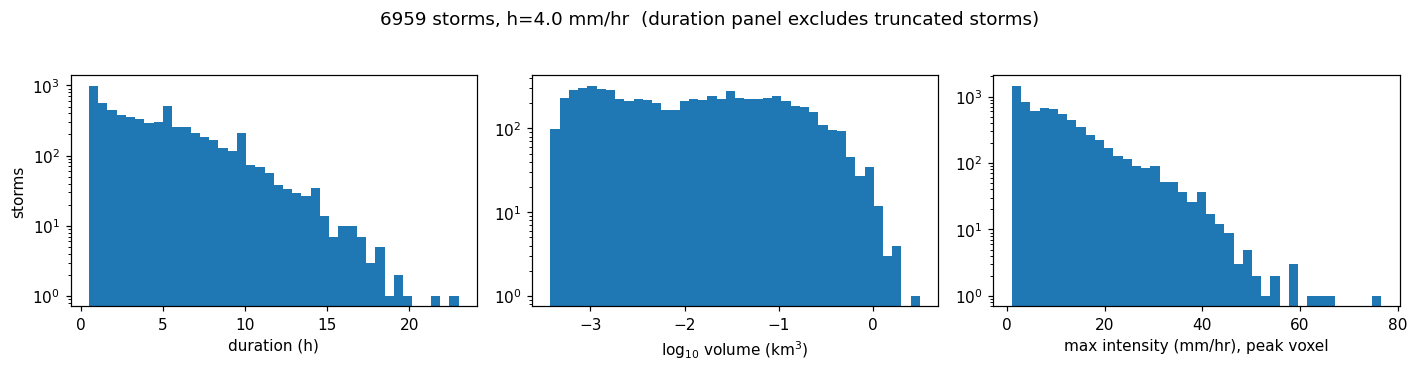

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].hist(clean.duration_h, bins=40)
axes[0].set_xlabel("duration (h)"); axes[0].set_ylabel("storms")
axes[1].hist(np.log10(df.total_volume_km3.clip(lower=1e-6)), bins=40)
axes[1].set_xlabel("log$_{10}$ volume (km$^3$)")
axes[2].hist(df.max_intensity_mm_hr, bins=40)
axes[2].set_xlabel("max intensity (mm/hr), peak voxel")
for a in axes: a.set_yscale("log")
fig.suptitle(f"{len(df)} storms, h={PROMINENCE} mm/hr  "
             f"(duration panel excludes truncated storms)", y=1.04)
fig.tight_layout()

## 7. Tracks

The trackline is the volume-weighted centroid at each timestep. Start and end
location are its first and last vertex.

The AOI includes ocean deliberately: most storms here form over water and move
onto land, so the sea carries the early life of the track.

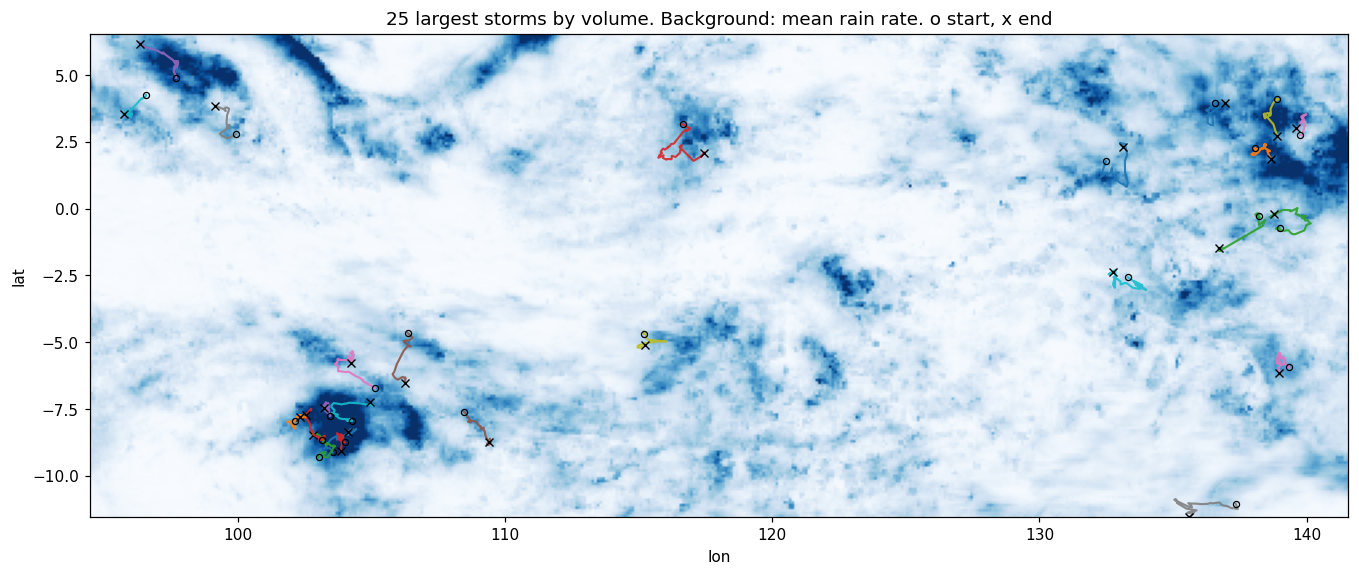

In [9]:
top = df.sort_values("total_volume_km3", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.imshow(np.nanmean(R, axis=0), origin="lower", cmap="Blues",
          extent=[da.lon.values[0], da.lon.values[-1],
                  da.lat.values[0], da.lat.values[-1]],
          vmax=np.nanpercentile(np.nanmean(R, axis=0), 99))
for _, s in top.iterrows():
    lats = [p[1] for p in s.track]; lons = [p[2] for p in s.track]
    ax.plot(lons, lats, lw=1.4, alpha=.9)
    ax.plot(lons[0], lats[0], "o", ms=4, mfc="none", mec="k", mew=.8)
    ax.plot(lons[-1], lats[-1], "x", ms=5, mec="k", mew=.9)
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_title(f"25 largest storms by volume. Background: mean rain rate. "
             f"o start, x end")
fig.tight_layout()

## 8. Severity

Storms are ranked against a reference population. What the rank *means* depends
entirely on how long that record is: under ten years it is a **percentile**, and
only a longer record earns the phrase *return period*. `severity.fit` decides
this itself and records which applies, so a caption cannot get it wrong.

Bands are stated as **exceedance rates** (storms per year) rather than
percentiles. At h=4 the catalogue holds about 449,000 storms a year, so p99 is
exceeded roughly 4,500 times a year and percentile bands would leave the upper
classes empty.

If no multi-year catalogue exists, this falls back to ranking against the current
window and says so. Building a real reference needs a **local archive**: a year
over the online source would exceed the 31-day ceiling in `config.MAX_ONLINE_DAYS`.

In [10]:
from config import DATA_PROCESSED

# A severity class is only meaningful against a reference population. Prefer a
# multi-year catalogue; fall back to THIS WINDOW so the notebook stays runnable
# with no local archive, which is what its header promises.
REF = DATA_PROCESSED / "catalogue_final_2020_h4.parquet"

if REF.exists():
    ref = pd.read_parquet(REF, columns=[
        "total_volume_km3", "max_intensity_mm_hr",
        "truncated_time", "truncated_space"])
    ref_years, ref_label = 1.0, "the 2020 catalogue"
else:
    ref = df
    ref_years = max((pd.to_datetime(END) - pd.to_datetime(START)).days + 1, 1) / 365.25
    ref_label = "THIS WINDOW ONLY"
    print("No multi-year catalogue found, so severity is ranked against this")
    print("window alone. That says 'big for these few days', NOT 'big for")
    print("Indonesia'. Build a proper reference with a local archive:")
    print("    python src/build_year.py --year 2020 --source local")
    print()

scale = severity.fit(ref, n_years=ref_years)
print(f"reference: {ref_label}")
print(scale.describe())

cls = scale.classify(df.total_volume_km3.values, df.max_intensity_mm_hr.values)
df["severity"] = cls.severity.values
print()
print(df.severity.value_counts()
        .reindex(severity.CLASS_NAMES).dropna().to_string())

reference: the 2020 catalogue
SeverityScale[all] n=391,527 storms over 1.0 yr, basis=percentile  (record too short for return periods; percentile only)
  bands by percentile
  volume     p90=0.1488, p99=0.5864 km3
  intensity  p90=23.1, p99=40.1 mm/hr

severity
very low      5828
low            268
moderate        22
medium         441
heavy          273
very heavy      33
intense         18
severe          64
extreme         12


## 9. Save

Parquet, with the trackline as WKT so it opens in any GIS, plus a sidecar
JSON of the parameters and the git revision that produced it.

In [11]:
path = catalogue.save(df, START, END, PRODUCT)
print(path)
df[[c for c in df.columns if c.startswith("param_")]].head(1).T

C:\Users\benny\OneDrive\Documents\Github\hujan-badai\data\processed\storms_final_2020-12-01_2020-12-05.parquet


,0
param_method,mergetree
param_wet_threshold,1.0
param_prominence,4.0
param_min_voxels,6
param_source,opendap
param_product,final
param_start,2020-12-01
param_end,2020-12-05
param_git_rev,f25480c+dirty
param_built_utc,2026-09-28T01:50:54+00:00


## Caveats to carry with any result from this notebook

1. **No validation.** No gauge or radar comparison exists for Indonesia here.
   This is a catalogue, not a measurement of skill.
2. **The storm count depends on `PROMINENCE`**, roughly halving per doubling, and
   the merge tree and watershed produce qualitatively *different populations* at
   the same `h`. Quote both the value and the method with every number.
3. **Volume is safe, counts are not.** An 8x change in `h` moves captured volume
   1.3%. Prefer volume-based and comparative statistics over absolute counts.
4. **Times are UTC.** Indonesia spans UTC+7 to +9. Segmentation is invariant to a
   time shift, but *interpretation* is not: the land-sea diurnal cycle only
   appears against a local clock (see notebook 02).
5. **Truncated storms are censored**, not wrong. Filter on the flags before
   quoting any duration or volume distribution.
6. **Runs differ.** IMERG Late reads about 9% higher in volume than Final, and
   Final ends 2025-09-30.
7. **A domain aggregate hides regimes.** The monsoonal south varies 54x through
   the year where the domain average says 1.9x. Regional breakdowns are in
   notebook 02.

Every claim above is numbered in [docs/findings.md](../docs/findings.md) with the
command that produced it.